In [4]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from edge_pydb import EdgeTable
from edge_pydb.plotting import imarrayplot

#load data tables
tglobal = EdgeTable('ecalifa_leda.csv', 
                    cols=['Name', 'ledaRA', 'ledaDE', 'ledaPA', 'ledaIncl', 'ledaD25', 'ledaAxIncl'])
tcalifa = EdgeTable('ecalifa_global.csv',
                    cols=['Name', 'Re'])
tglobal.join(tcalifa)
ssptab = EdgeTable('edge_carma_allpix.pipe3d.hdf5', 
                   path='SSP', 
                   cols=['Name', 'ix', 'iy', 'ra_abs', 'dec_abs', 'sigstar', 'fe_medflx'])

#find nearest pixel to true center and return coordinates and offset in arcsecs
def get_galaxy_center_pixel(galname):
    #check if galaxy is present

    # get LEDA coordinates for this galaxy
    galdata = tglobal[tglobal['Name'] == galname]
    leda_ra = float(galdata['ledaRA'][0])
    leda_dec = float(galdata['ledaDE'][0])
    leda_coord = SkyCoord(ra=leda_ra*u.deg, dec=leda_dec*u.deg, frame='fk5')

    #check if galaxy exists in table
    if len(galdata) == 0:
        print("Galaxy " + galname + " not found in table.")
        return None

    #get SSP pixels
    galaxy_rows = ssptab[ssptab['Name'] == galname]
    pixel_coords = SkyCoord(ra=np.array(galaxy_rows['ra_abs'])*u.deg,
                            dec=np.array(galaxy_rows['dec_abs'])*u.deg,
                            frame='fk5')
    
    #find the nearest pixel to center
    separations = leda_coord.separation(pixel_coords)
    nearest_idx = np.argmin(separations)
    ix = int(galaxy_rows['ix'][nearest_idx])
    iy = int(galaxy_rows['iy'][nearest_idx])
    pixel_ra = float(galaxy_rows['ra_abs'][nearest_idx])
    pixel_dec = float(galaxy_rows['dec_abs'][nearest_idx])
    offset_arcsec = separations[nearest_idx].to(u.arcsec).value

    return ix, iy, pixel_ra, pixel_dec, offset_arcsec

In [3]:
#overall wrapper function for plotting center
def plot_galaxy_center(galname, plot_column='sigstar',
                       marker_style='x', marker_color='red', 
                       marker_size=20, marker_edgewidth=2, cmap='jet',
                       title_fontsize=16):
    # get center pixel coords for galaxy
    ix, iy, _, _, offset_arcsec = get_galaxy_center_pixel(galname)
    if ix is None:
        print("galaxy " + galname + " not found in tables.")
        return

    # setup figure parameters
    plt.rcParams.update({'font.size': 22})
    fig, ax = plt.subplots(figsize=(6,6))

    # select rows for this galaxy
    galaxy_rows = ssptab[ssptab['Name'] == galname]

    # plot base galaxy image
    from edge_pydb.plotting import imarrayplot
    img, xlims, ylims = imarrayplot(
        x=galaxy_rows['ix'],
        y=galaxy_rows['iy'],
        imval=galaxy_rows[plot_column],
        axes=ax,
        cmap=cmap
    )

    # fix axis limits
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_aspect('equal')

    # overlay center marker
    ax.plot(ix, iy,
        marker=marker_style,
        color='red',
        markersize=25,
        markeredgewidth=4,
        markeredgecolor='black')

    # title and display plot
    plt.title(galname + " Center (offset: " + str(round(offset_arcsec,2)) + " arcsec)",
              fontsize=title_fontsize)
    plt.show()
    return ix, iy



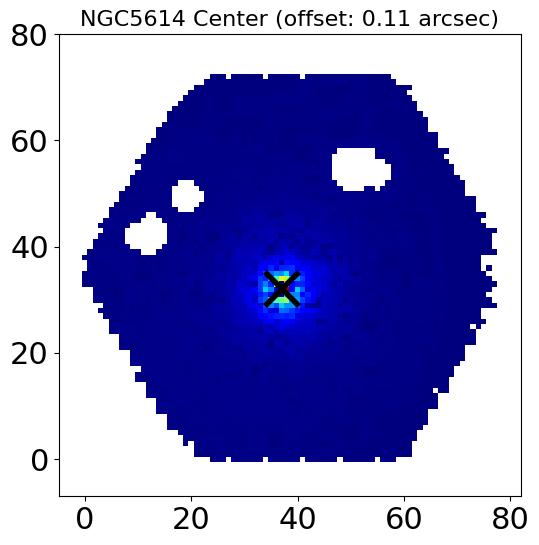

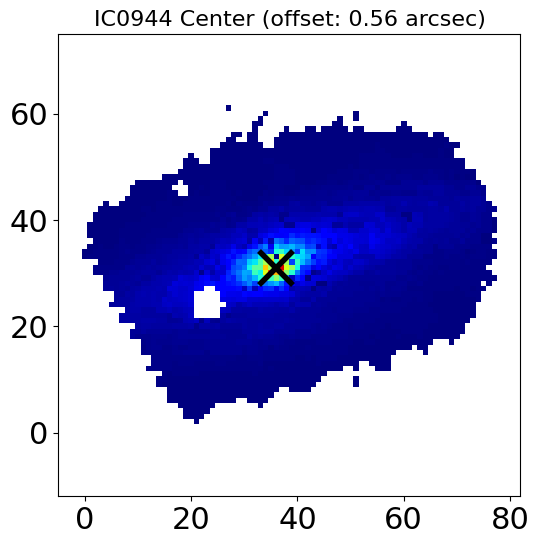

(36, 31)

In [3]:
#testing
plot_galaxy_center('NGC5614')
plot_galaxy_center('IC0944')

In [4]:
#rough work for plotting radius
import numpy as np
import matplotlib.pyplot as plt
from astropy.coordinates import SkyCoord
import astropy.units as u
from matplotlib.patches import Ellipse
from edge_pydb.plotting import imarrayplot

def compute_galaxy_ellipse(galname, plot_column='sigstar', cmap='jet', ax=None):
    galaxy_rows = ssptab[ssptab['Name'] == galname]
    galdata = tglobal[tglobal['Name'] == galname]

    ix_center, iy_center, _, _, _ = get_galaxy_center_pixel(galname)
    pix_scale = np.abs(galaxy_rows['dec_abs'][1] - galaxy_rows['dec_abs'][0]) * 3600

    Re_arcsec = float(galdata['Re'][0])
    ax_incl_deg = float(galdata['ledaAxIncl'][0])
    pa_deg = float(galdata['ledaPA'][0])
    a_pix = Re_arcsec / pix_scale
    b_pix = a_pix * np.cos(np.radians(ax_incl_deg))
    theta_deg = pa_deg + 90

    ix_panel = ix_center - np.min(galaxy_rows['ix'])
    iy_panel = iy_center - np.min(galaxy_rows['iy'])

    # use passed axes if available, otherwise make new one
    if ax is None:
        fig, ax = plt.subplots(figsize=(6,6))

    img, xlims, ylims = imarrayplot(
        x=galaxy_rows['ix'],
        y=galaxy_rows['iy'],
        imval=galaxy_rows[plot_column],
        axes=ax,
        cmap=cmap
    )
    ax.set_xlim(xlims)
    ax.set_ylim(ylims)
    ax.set_aspect('equal')

    ell = Ellipse(
        (ix_panel, iy_panel),
        width=2*a_pix,
        height=2*b_pix,
        angle=theta_deg,
        edgecolor='red',
        facecolor='none',
        lw=2
    )
    ax.add_patch(ell)
    ax.plot(ix_panel, iy_panel, marker='o', color='red',
            markersize=14, markeredgewidth=3, markeredgecolor='black')

    ax.set_title(f'{galname}', fontsize=12)
    return ax

<Axes: title={'center': 'IC0944'}>

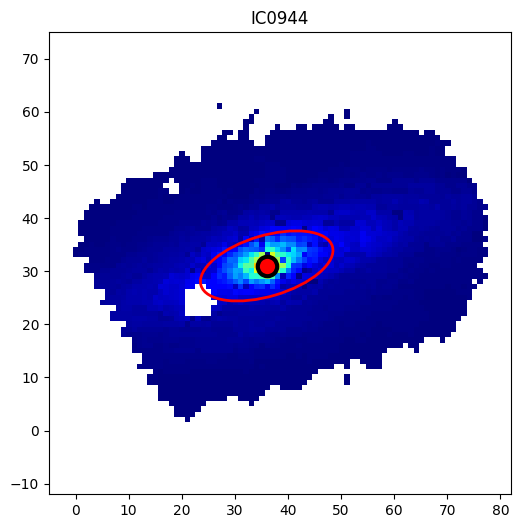

In [4]:
compute_galaxy_ellipse('IC0944')

In [5]:
gallist = list(np.unique(ssptab['Name']))
print(gallist)

['ARP220', 'IC0480', 'IC0540', 'IC0944', 'IC1151', 'IC1199', 'IC1683', 'IC2247', 'IC2487', 'IC4566', 'IC5376', 'NGC0444', 'NGC0447', 'NGC0477', 'NGC0496', 'NGC0523', 'NGC0528', 'NGC0551', 'NGC1167', 'NGC2253', 'NGC2347', 'NGC2410', 'NGC2480', 'NGC2487', 'NGC2623', 'NGC2639', 'NGC2730', 'NGC2880', 'NGC2906', 'NGC2916', 'NGC2918', 'NGC3303', 'NGC3381', 'NGC3687', 'NGC3811', 'NGC3815', 'NGC3994', 'NGC4047', 'NGC4149', 'NGC4185', 'NGC4210', 'NGC4211NED02', 'NGC4470', 'NGC4644', 'NGC4676A', 'NGC4711', 'NGC4961', 'NGC5000', 'NGC5016', 'NGC5056', 'NGC5205', 'NGC5218', 'NGC5394', 'NGC5406', 'NGC5480', 'NGC5485', 'NGC5520', 'NGC5614', 'NGC5633', 'NGC5657', 'NGC5682', 'NGC5732', 'NGC5784', 'NGC5876', 'NGC5908', 'NGC5930', 'NGC5934', 'NGC5947', 'NGC5953', 'NGC5980', 'NGC6004', 'NGC6021', 'NGC6027', 'NGC6060', 'NGC6063', 'NGC6081', 'NGC6125', 'NGC6146', 'NGC6155', 'NGC6168', 'NGC6186', 'NGC6301', 'NGC6310', 'NGC6314', 'NGC6361', 'NGC6394', 'NGC6478', 'NGC7738', 'NGC7819', 'UGC00809', 'UGC03253', '

In [2]:
def process_galaxies(hdf5_path):
    # Import required libraries
    import h5py
    import matplotlib.pyplot as plt

    # Load galaxy data from the HDF5 file
    with h5py.File(hdf5_path, 'r') as f:
        galaxy_names = list(f.keys())

        # Loop over each galaxy in the dataset
        for galaxy_name in galaxy_names:
            print("Processing... " + galaxy_names)

            # Load FITS image for the galaxy
            fits_file = f[galaxy_name]['image_path'][()].decode('utf-8')
            data = load_fits_data(fits_file)

            # Compute ellipse parameters for visualization
            ellipse_params = compute_galaxy_ellipse(galaxy_name)

            # Plot the galaxy with its corresponding ellipse
            plot_galaxy_with_ellipse(data, ellipse_params, galaxy_name)


def load_fits_data(fits_file):
    # Import FITS file utilities
    from astropy.io import fits

    # Open and read FITS image data
    with fits.open(fits_file) as hdul:
        data = hdul[0].data

    # Return 2D image array
    return data


def plot_galaxy_with_ellipse(data, ellipse_params, galaxy_name):
    # Import plotting tools
    import matplotlib.pyplot as plt
    from matplotlib.patches import Ellipse

    # Create figure and axis for plotting
    fig, ax = plt.subplots(figsize=(5, 5))

    # Display the galaxy image
    ax.imshow(data, cmap='gray', origin='lower')

    # Unpack ellipse parameters
    x0, y0, Re, ellipticity, pa = ellipse_params

    # Compute ellipse axes
    a = Re
    b = Re * (1 - ellipticity)

    # Overlay ellipse on the image
    ellipse = Ellipse((x0, y0), 2 * a, 2 * b, angle=pa, edgecolor='red', facecolor='none', lw=1.2)
    ax.add_patch(ellipse)

    # Add title and remove axis ticks
    ax.set_title(galaxy_name)
    ax.axis('off')

    # Show plot
    plt.show()


def gridplot_overlay(galaxy_data_list):
    # Import plotting library
    import matplotlib.pyplot as plt

    # Set up grid layout
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))

    # Flatten axes for easy iteration
    axes = axes.flatten()

    # Loop through galaxies and axes
    for i, (data, ellipse_params, name) in enumerate(galaxy_data_list):
        ax = axes[i]

        # Show galaxy image
        ax.imshow(data, cmap='gray', origin='lower')

        # Extract and draw ellipse overlay
        x0, y0, Re, ellipticity, pa = ellipse_params
        a = Re
        b = Re * (1 - ellipticity)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x0, y0), 2 * a, 2 * b, angle=pa, edgecolor='red', facecolor='none', lw=1)
        ax.add_patch(ellipse)

        # Add galaxy label
        ax.set_title(name, fontsize=9)
        ax.axis('off')

    # Adjust layout spacing
    plt.tight_layout()
    plt.show()

In [7]:
#build overall gridplot_v2
def gridplot_v2(gallist, plot_column='sigstar', cmap='jet', nx=3, ny=3):
    fig = plt.figure(figsize=(18, 14))
    print(f'Plotting {len(gallist)} galaxies with overlays')

    for i, galname in enumerate(gallist):
        if i >= nx * ny:
            break  # only fill one page worth of panels

        ax = plt.subplot(ny, nx, i + 1)
        compute_galaxy_ellipse(galname, plot_column=plot_column, cmap=cmap, ax=ax)
        ax.xaxis.set_ticks([])
        ax.yaxis.set_ticks([])
        ax.set_aspect('equal')

    fig.subplots_adjust(hspace=0.1, wspace=0.05)
    plt.show()


Plotting 4 galaxies with overlays


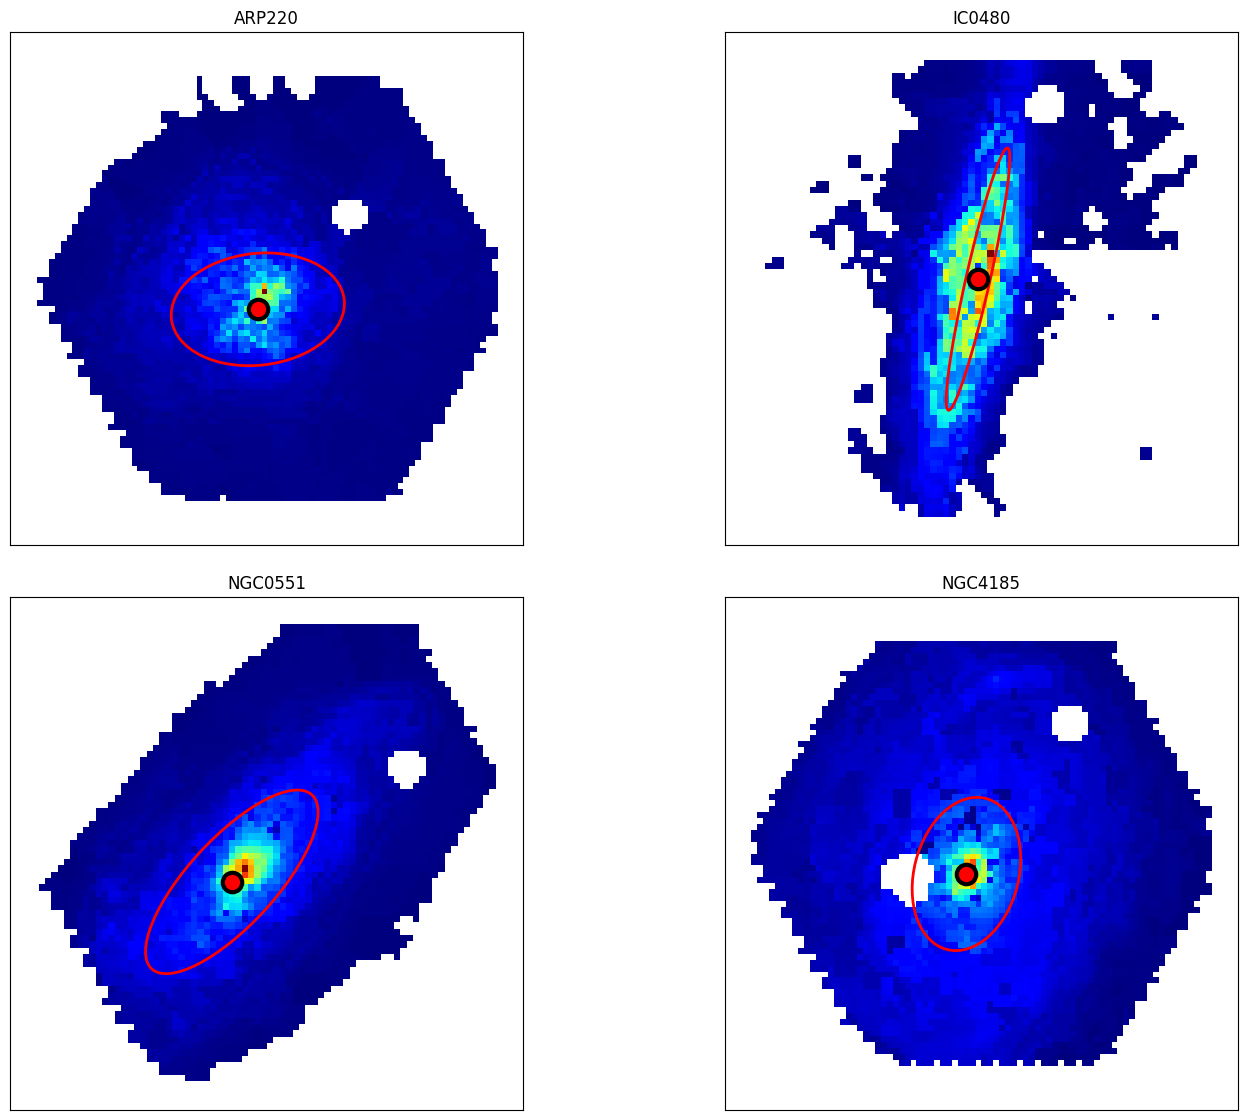

In [8]:
#testing overall new gridplot function
test_galaxies = ['ARP220', 'IC0480', 'NGC0551', 'NGC4185']
gridplot_v2(test_galaxies, plot_column='sigstar', cmap='jet', nx=2, ny=2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def gridplotv2(gallist, ncols=3, save_path="galaxy_panel.pdf", plot_column="sigstar", cmap="jet", rows_per_page = 3):
    # Compute grid shape
    n_gal = len(gallist)
    nrows = int(np.ceil(n_gal / ncols))

    # Calculate number of pages
    n_pages = int(np.ceil(nrows / rows_per_page))
    print("Number of pages needed: " + str(n_pages))

    # Create figure
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
    axes = np.atleast_1d(axes).flatten()

    for i, galname in enumerate(gallist):
        ax = axes[i]

        # Compute and plot the galaxy with overlays
        compute_galaxy_ellipse(galname, plot_column=plot_column, cmap=cmap, ax=ax)

        # Add title
        ax.set_title(galname)
        ax.axis("off")

    # Hide any empty axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    #plt.show()
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.close(fig)
    print("✅ Saved grid plot as PDF:", save_path)


Number of pages needed: 1


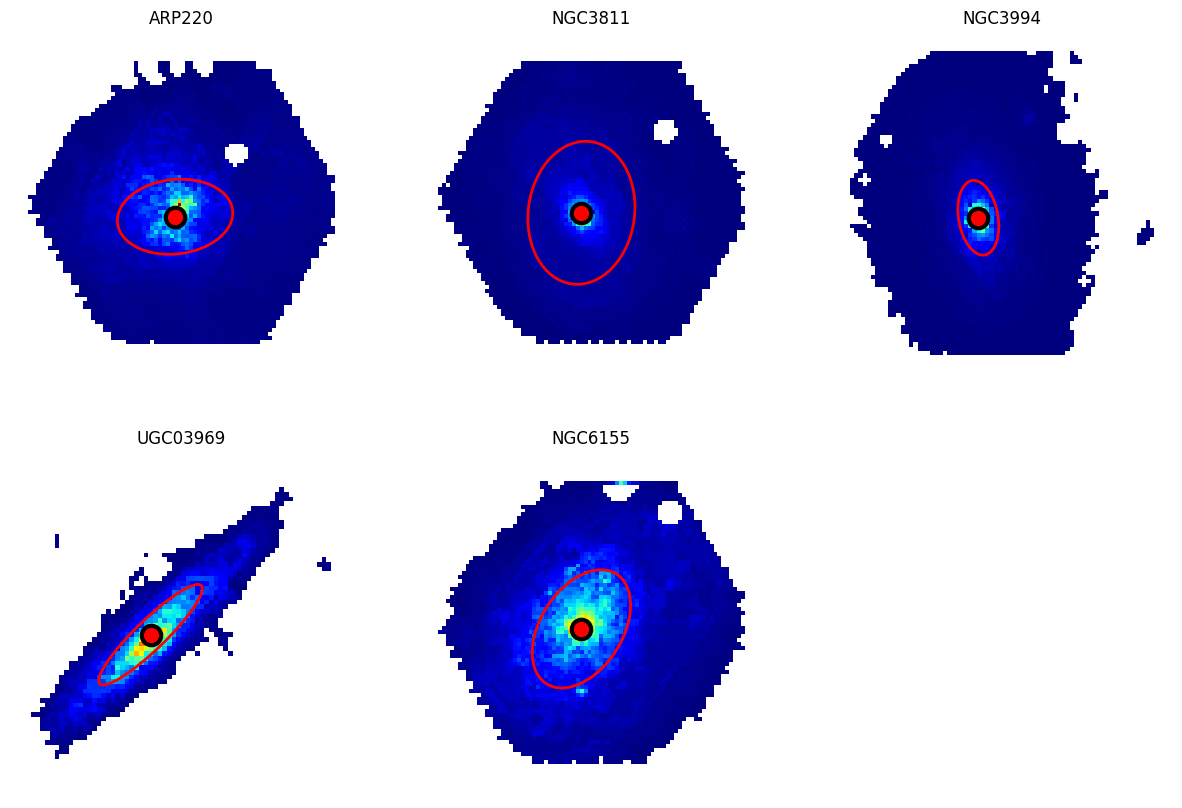

✅ Saved grid plot as PDF: galaxy_trial.pdf


<Figure size 640x480 with 0 Axes>

In [14]:
gallist = ['ARP220', 'NGC3811', 'NGC3994', 'UGC03969', 'NGC6155']
gridplotv2(gallist, ncols = 3, save_path = 'galaxy_trial.pdf')

Nummber of pages needed: 9


IndexError: index 0 is out of bounds for axis 0 with size 0

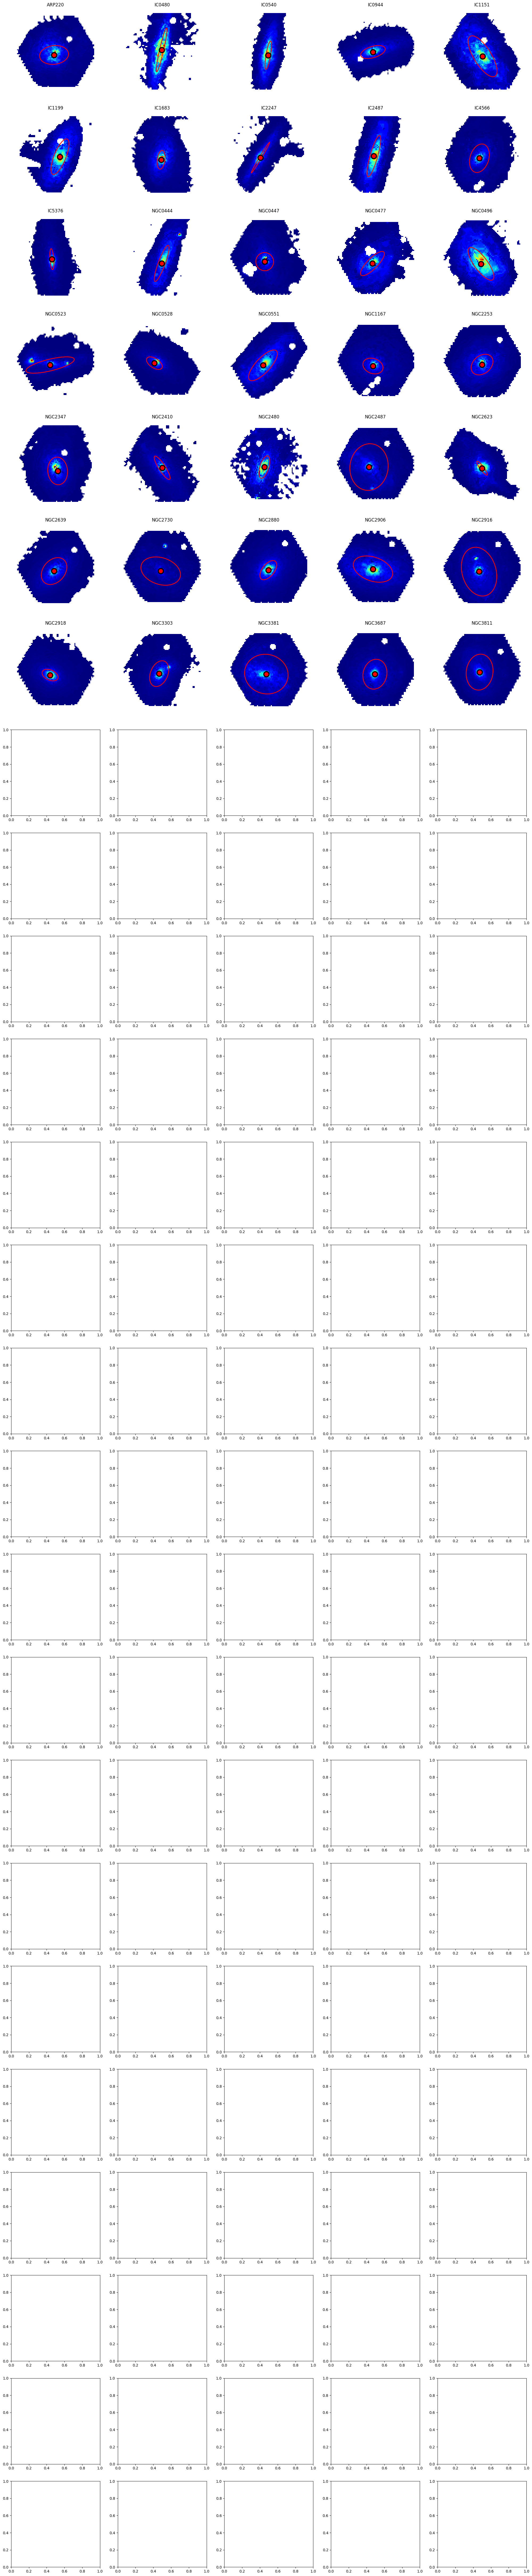

In [ ]:
#gallist = list(np.unique(ssptab['Name']))
#gridplotv2(gallist, ncols = 5, save_path = 'galaxy_panel.pdf')